# 07 · היתוך ושיוך עם תכונות / סיווג (Attributes & Classification)
**מלווה את ההרצאה:** *Fusion and Association with Attributes/Classification* — Yaakov Bar-Shalom.

> ⚠️ שקופיות הרצאה זו **אינן** ב-PDF. המחברת מבוססת על הספרות הקנונית ועל התייחסות Blasch 
> במבוא ל-'Object level — Bayes versus Dempster-Shafer'.

עד כה עסקנו במצב **קינמטי** (מיקום/מהירות). תכונות (attributes) — כמו **מחלקת המטרה** (class/ID) — 
מוסיפות מימד נוסף ל-fusion: הן משפרות גם את ה**שיוך** (אסור לשייך מדידת 'משאית' למסלול 'מטוס') וגם את ה**זיהוי**.

## א. סיווג בייסיאני וצבירה רצופה (Sequential Bayesian Fusion)
נתון prior על המחלקות $P(c)$ ו'מטריצת בלבול' (confusion matrix) $P(z\mid c)$ של החיישן. 
כל מדידה מעדכנת את ההסתברות הפוסטריורית בכלל בייס, וכך **צוברים ביטחון** על פני זמן/חיישנים:
$$P(c\mid z_{1:k}) \propto P(z_k\mid c)\,P(c\mid z_{1:k-1})$$

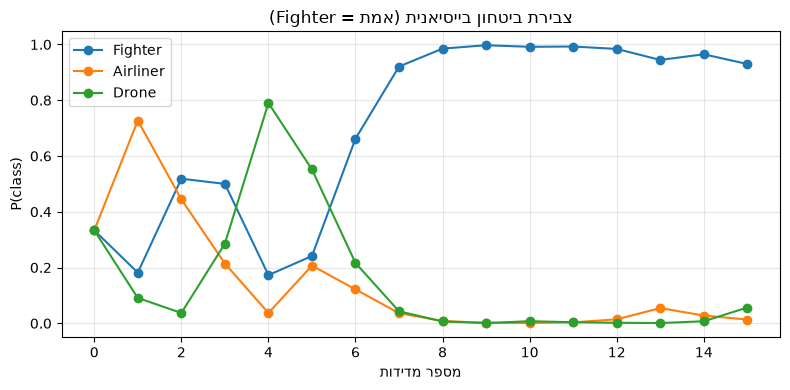

פוסטריור סופי: {'Fighter': np.float64(0.93), 'Airliner': np.float64(0.013), 'Drone': np.float64(0.057)}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(9)
classes = ['Fighter','Airliner','Drone']
# מטריצת בלבול: שורה=מחלקה אמיתית, עמודה=דיווח החיישן
C = np.array([[0.70,0.20,0.10],
              [0.15,0.80,0.05],
              [0.10,0.10,0.80]])

def bayes_fuse(prior, reports, C):
    p = prior.copy(); hist=[p.copy()]
    for r in reports:
        p = C[:,r]*p; p/=p.sum(); hist.append(p.copy())
    return p, np.array(hist)

true_c = 0  # Fighter
reports = [np.argmax(rng.multinomial(1, C[true_c])) for _ in range(15)]
post, hist = bayes_fuse(np.ones(3)/3, reports, C)
plt.figure(figsize=(8,4))
for j,name in enumerate(classes): plt.plot(hist[:,j],'o-',label=name)
plt.title(f'צבירת ביטחון בייסיאנית (אמת = {classes[true_c]})')
plt.xlabel('מספר מדידות'); plt.ylabel('P(class)'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('פוסטריור סופי:', dict(zip(classes, np.round(post,3))))

## ב. תורת ההחלטה: מטריצת בלבול ועלות סיכון
ההחלטה אינה תמיד 'המחלקה הסבירה ביותר' — אפשר לשקלל **עלויות שגיאה** (למשל סיווג שגוי של מטוס נוסעים כמטרה עוין). 
ההחלטה הבייסיאנית האופטימלית ממזערת את הסיכון $R(a\mid z)=\sum_c L(a,c)\,P(c\mid z)$.

In [2]:
# הערכת ביצועי המסווג ע"י סימולציית מטריצת בלבול אמפירית (החלטת MAP אחרי 5 מדידות)
K=5; trials=4000; conf=np.zeros((3,3))
for _ in range(trials):
    tc=rng.integers(3)
    rep=[np.argmax(rng.multinomial(1,C[tc])) for _ in range(K)]
    post,_=bayes_fuse(np.ones(3)/3, rep, C)
    conf[tc, np.argmax(post)]+=1
conf=conf/conf.sum(1,keepdims=True)
print('מטריצת בלבול אחרי %d מדידות (שורה=אמת, עמודה=החלטה):'%K)
print('         '+'  '.join(f'{c:>9}' for c in classes))
for i,c in enumerate(classes): print(f'{c:>9} '+'  '.join(f'{v:9.2f}' for v in conf[i]))
print(f'דיוק כולל = {np.trace(conf)/3:.1%}  (לעומת ~{np.trace(C)/3:.1%} ממדידה בודדת)')

מטריצת בלבול אחרי 5 מדידות (שורה=אמת, עמודה=החלטה):
           Fighter   Airliner      Drone
  Fighter      0.93       0.06       0.02
 Airliner      0.06       0.93       0.01
    Drone      0.02       0.01       0.97
דיוק כולל = 94.2%  (לעומת ~76.7% ממדידה בודדת)


## ג. Dempster–Shafer מול Bayes
תורת ה**עדויות (Dempster-Shafer)** מכלילה את בייס ומאפשרת לייצג **בורות (ignorance)** ע"י הקצאת מסה 
לקבוצות מחלקות (לא רק ליחידים). כלל השילוב של דמפסטר:
$$m_{12}(A)=\frac{1}{1-K}\sum_{B\cap C=A} m_1(B)\,m_2(C), \quad K=\sum_{B\cap C=\varnothing} m_1(B)\,m_2(C)$$
כאשר $K$ הוא ה**קונפליקט**. כשהקונפליקט גבוה, נורמליזציית דמפסטר עלולה לתת תוצאות לא-אינטואיטיביות (פרדוקס Zadeh).

In [3]:
from itertools import combinations
# מסגרת הבחנה: {F,A,D}; מסות מוקצות לתת-קבוצות (frozenset)
frame=['F','A','D']
subsets=[frozenset(s) for r in range(1,4) for s in combinations(frame,r)]
def ds_combine(m1,m2):
    out={}; K=0.0
    for B,mb in m1.items():
        for Cc,mc in m2.items():
            inter=B&Cc
            if inter: out[inter]=out.get(inter,0)+mb*mc
            else: K+=mb*mc
    return {k:v/(1-K) for k,v in out.items()}, K

# חיישן 1 בטוח יחסית ב-Fighter אך משאיר בורות; חיישן 2 תומך ב-Fighter/Drone
m1={frozenset(['F']):0.6, frozenset(['F','A']):0.2, frozenset(frame):0.2}
m2={frozenset(['F']):0.5, frozenset(['D']):0.3, frozenset(frame):0.2}
comb,K=ds_combine(m1,m2)
print(f'קונפליקט K = {K:.3f}')
for s,v in sorted(comb.items(), key=lambda kv:-kv[1]):
    print(f'  m({set(s)}) = {v:.3f}')
# Belief ו-Plausibility ל-{F}
A=frozenset(['F'])
bel=sum(v for s,v in comb.items() if s<=A)
pl =sum(v for s,v in comb.items() if s&A)
print(f'Bel(Fighter)={bel:.3f}, Pl(Fighter)={pl:.3f}  (מרווח אי-הוודאות)')

קונפליקט K = 0.240
  m({'F'}) = 0.816
  m({'D'}) = 0.079
  m({'A', 'F'}) = 0.053
  m({'F', 'A', 'D'}) = 0.053
Bel(Fighter)=0.816, Pl(Fighter)=0.921  (מרווח אי-הוודאות)


## סיכום
* תכונות/מחלקה משפרות גם **שיוך** וגם **זיהוי**; היתוך בייסיאני **צובר ביטחון** על פני מדידות.
* **תורת ההחלטה** מאפשרת לשקלל עלויות שגיאה אסימטריות.
* **Dempster-Shafer** מייצג בורות במפורש; להיזהר מקונפליקט גבוה.
* בפועל, fusion מודרני משלב סיווג קינמטי+תכונתי (joint tracking & classification) — חיבור בין מחברות 03–04 לכאן.